# Gestão de Algoritmos de Machine Learning com MLFlow

## Projeto do Aluno:
Você trabalha na Delivery Fast, uma empresa que tem como foco levar o alimento do 
restaurante para casa do cliente no menor tempo possível, portanto você foi 
escolhido para realizar a predição do tempo de entrega que é mostrada ao cliente. É 
de suma importância dessa predição ser o mais correta possível para a experiência 
seja agradável para o usuário.
Neste cenário, você deverá prever para um determinado pedido de delivery o tempo 
total de entrega em segundos.

Os dados contém entregas realizadas pela Delivery Fast no ano de 2015, cada 
linha do arquivo é referente a uma entrega única, todos os valores monetários 
são em dólares e todos os de duração estão em segundos.

| Nome da coluna                             | Tipo do dado | Descrição                                                                                     |
|--------------------------------------------|--------------|-----------------------------------------------------------------------------------------------|
| market_id                                  | Inteiro      | A cidade/região na qual a empresa atua                                                        |
| created_at                                 | Data e Hora  | Momento em que o pedido foi realizado pelo cliente                                            |
| actual_delivery_time                       | Data e Hora  | Momento em que o pedido foi entregue ao cliente                                               |
| store_id                                   | Inteiro      | Identificador do restaurante onde o pedido foi realizado                                      |
| store_primary_category                     | Texto        | Categoria principal do restaurante                                                            |
| order_protocol                             | Inteiro      | Modo pelo qual o restaurante recebe pedidos da empresa                                        |
| total_items                                | Inteiro      | Total de itens do pedido                                                                      |
| subtotal                                   | Inteiro      | Valor total do pedido (em centavos)                                                           |
| num_distinct_items                         | Inteiro      | Número de itens distintos no pedido                                                           |
| min_item_price                             | Inteiro      | Preço do item mais barato no pedido (em centavos)                                             |
| max_item_price                             | Inteiro      | Preço do item mais caro no pedido (em centavos)                                               |
| total_onshift_dashers                      | Inteiro      | Número de entregadores disponíveis em até 16 km do restaurante no momento da criação do pedido |
| total_busy_dashers                         | Inteiro      | Subconjunto de `total_onshift_dashers` que está atualmente trabalhando em um pedido           |
| total_outstanding_orders                   | Inteiro      | Número de pedidos em um raio de 10 milhas que estão sendo processados atualmente              |
| estimated_order_place_duration             | Inteiro      | Tempo estimado para o restaurante receber o pedido da Delivery Fast (em segundos)             |
| estimated_store_to_consumer_driving_duration | Inteiro    | Tempo estimado de viagem entre o restaurante e o consumidor (em segundos)                     |

- Solução esperada:

Portanto se espera que você construa um modelo para prever a duração total da 
entrega em segundos.

- Dicas:

Atenção, a variável alvo não foi criada, portanto encontre a forma de como criá-la;

Atenção para os possíveis preprocessamento e tratamento das variáveis

Planeje antes de codificar e como a predição será utilizada

Entenda qual a natureza do problema a ser resolvido

Interligue os conhecimentos dos cursos da Comunidade DS

## BIBLIOTECAS

In [ ]:
import pandas                as pd
import numpy                 as np
import matplotlib.pyplot     as plt

from sklearn.model_selection import train_test_split

## CARREGAMENTO DOS DADOS

In [2]:
df_raw = pd.read_csv('data/raw/dados.csv')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

## 1.0 DESCRIÇÃO DOS DADOS

In [3]:
#Quantidade de linhas e colunas:
df_raw.shape

(197428, 16)

In [4]:
df_raw.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [5]:
#tipos de dados
df_raw.dtypes

market_id                                       float64
created_at                                       object
actual_delivery_time                             object
store_id                                          int64
store_primary_category                           object
order_protocol                                  float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_order_place_duration                    int64
estimated_store_to_consumer_driving_duration    float64
dtype: object

In [6]:
#verificando nulos:

(df_raw.isna().sum() / df_raw.shape[0]) * 100

market_id                                       0.499929
created_at                                      0.000000
actual_delivery_time                            0.003546
store_id                                        0.000000
store_primary_category                          2.411006
order_protocol                                  0.503981
total_items                                     0.000000
subtotal                                        0.000000
num_distinct_items                              0.000000
min_item_price                                  0.000000
max_item_price                                  0.000000
total_onshift_dashers                           8.236927
total_busy_dashers                              8.236927
total_outstanding_orders                        8.236927
estimated_order_place_duration                  0.000000
estimated_store_to_consumer_driving_duration    0.266426
dtype: float64

In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

### 1.1 VAIÁVEL ALVO

In [8]:
#variável alvo (time to deliver seconds: ttd_sec)

df_raw["created_at"] = pd.to_datetime(df_raw["created_at"])
df_raw["actual_delivery_time"] = pd.to_datetime(df_raw["actual_delivery_time"])

df_raw["ttd_sec"] = (
    df_raw["actual_delivery_time"] - df_raw["created_at"]
).dt.total_seconds()

In [9]:
df_raw["ttd_sec"].describe()

count    1.974210e+05
mean     2.908257e+03
std      1.922961e+04
min      1.010000e+02
25%      2.104000e+03
50%      2.660000e+03
75%      3.381000e+03
max      8.516859e+06
Name: ttd_sec, dtype: float64

In [10]:
#outliers
df_raw["ttd_sec"].quantile([0.95, 0.99, 0.999])


0.950    4872.00
0.990    6474.80
0.999    9934.86
Name: ttd_sec, dtype: float64

In [47]:
#removendo outliers:
q999 = df_raw["ttd_sec"].quantile(0.999)
df1 = df_raw[df_raw["ttd_sec"] <= q999].copy()

array([[<Axes: title={'center': 'ttd_sec'}>]], dtype=object)

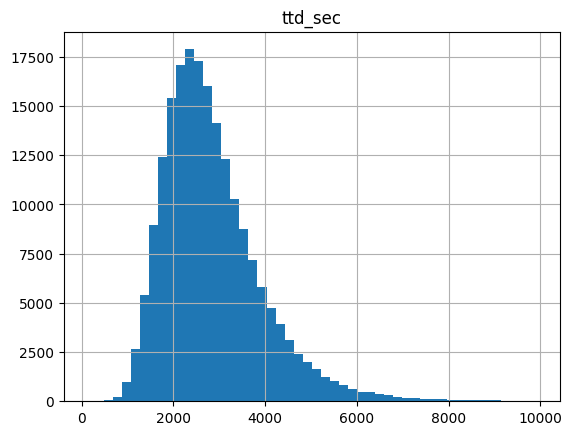

In [48]:
#distribuição da variável alvo:
df1.hist('ttd_sec', bins = 50)

### 1.2 VARIÁVEIS CATEGÓRICAS

In [49]:
#Cidade / região:
df1["market_id"] = df1["market_id"].astype("category")

#Modo de recebimento do pedido:
df1["order_protocol"] = df1["order_protocol"].astype("category")

#Restaurante:
df1["store_id"] = df1["store_id"].astype("category")

In [50]:
cat_attributes = df1.select_dtypes(include = ['object', 'category'])
cat_cols = cat_attributes.columns

In [51]:
#identificando categorias raras:
for col in cat_cols:
    print(f"\n--- {col} ---")
    freq = df1[col].value_counts(normalize=True)
    rare = freq[freq < 0.01]   # categorias com menos de 1%
    print("Categorias raras:")
    print(rare)


--- market_id ---
Categorias raras:
Series([], Name: proportion, dtype: float64)

--- store_id ---
Categorias raras:
store_id
6865    0.004746
1311    0.004371
314     0.004127
1686    0.003879
3937    0.003656
          ...   
4774    0.000005
4789    0.000005
2852    0.000005
2862    0.000005
2871    0.000005
Name: proportion, Length: 6742, dtype: float64

--- store_primary_category ---
Categorias raras:
store_primary_category
alcohol              0.009602
korean               0.009420
smoothie             0.008609
catering             0.008464
hawaiian             0.007783
middle-eastern       0.007783
dim-sum              0.005778
steak                0.005674
vegetarian           0.004385
burmese              0.004266
pasta                0.003284
persian              0.003154
french               0.002988
latin-american       0.002702
bubble-tea           0.002697
convenience-store    0.001803
cajun                0.001642
brazilian            0.001611
nepalese             0.001

In [52]:
#Quantas categorias raras existem:
for col in cat_cols:
    freq = df1[col].value_counts(normalize=True)
    rare_count = (freq < 0.0001).sum()
    print(f"{col}: {rare_count} categorias raras")


market_id: 0 categorias raras
store_id: 4419 categorias raras
store_primary_category: 7 categorias raras
order_protocol: 1 categorias raras


In [53]:
#Agrupando categorias raras de store_id e store_primary_category:
cols = ["store_id", "store_primary_category"]

for col in cols:
    freq = df1[col].value_counts(normalize=True)
    rare = freq[freq < 0.0001].index
    df1[col + '_grp'] = df1[col].replace(rare, "other")

C:\Users\samso\AppData\Local\Temp\ipykernel_18088\1961005169.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df1[col + '_grp'] = df1[col].replace(rare, "other")


In [54]:
df1['store_id_grp'].value_counts(normalize = True)

store_id_grp
other    0.157563
6865     0.004746
1311     0.004371
314      0.004127
1686     0.003879
           ...   
2888     0.000101
6690     0.000101
3032     0.000101
52       0.000101
50       0.000101
Name: proportion, Length: 2324, dtype: float64

In [55]:
df1['store_primary_category_grp'].value_counts(normalize = True)

store_primary_category_grp
american        0.100682
pizza           0.089917
mexican         0.088779
burger          0.056882
sandwich        0.052222
                  ...   
singaporean     0.000171
comfort-food    0.000145
moroccan        0.000130
cheese          0.000125
european        0.000114
Name: proportion, Length: 67, dtype: float64

## 2.0 ESTATÍSTICAS DOS DADOS

In [67]:
df2 = df1.copy()

### 2.1 VARIÁVEIS NUMÉRICAS

In [69]:
num_attributes = df2.select_dtypes(include = ['int64', 'float64'])

In [70]:
num_attributes.describe().T

,count,mean,std,min,25%,50%,75%,max
total_items,197223.0,3.196407,2.666777,1.0,2.0,3.0,4.0,411.0
subtotal,197223.0,2682.170979,1822.902674,0.0,1400.0,2200.0,3395.0,27100.0
num_distinct_items,197223.0,2.670829,1.630297,1.0,1.0,2.0,3.0,20.0
min_item_price,197223.0,686.116143,521.618933,-86.0,299.0,595.0,949.0,14700.0
max_item_price,197223.0,1159.486921,558.032323,0.0,800.0,1095.0,1395.0,14700.0
total_onshift_dashers,180978.0,44.817166,34.525947,-4.0,17.0,37.0,65.0,171.0
total_busy_dashers,180978.0,41.747853,32.144576,-5.0,15.0,34.0,62.0,154.0
total_outstanding_orders,180978.0,58.056581,52.659411,-6.0,17.0,41.0,85.0,285.0
estimated_order_place_duration,197223.0,308.545854,90.134539,0.0,251.0,251.0,446.0,2715.0
estimated_store_to_consumer_driving_duration,196697.0,545.283151,219.331796,0.0,382.0,544.0,702.0,2088.0


In [72]:
(df2[["total_onshift_dashers", "total_busy_dashers", 
"total_outstanding_orders", "min_item_price"]] < 0).sum()


total_onshift_dashers       21
total_busy_dashers          21
total_outstanding_orders    44
min_item_price              13
dtype: int64

In [84]:
df2.shape

(196898, 19)

In [ ]:
#removendo linhas negativas:
df2 = df2[
    (df2["total_onshift_dashers"] >= 0) &
    (df2["total_busy_dashers"] >= 0) &
    (df2["total_outstanding_orders"] >= 0) &
    (df2["min_item_price"] >= 0)
].copy()

df2.shape

(196898, 19)

In [83]:
(df2[["total_onshift_dashers", "total_busy_dashers", 
"total_outstanding_orders", "min_item_price"]] < 0).sum()

total_onshift_dashers       21
total_busy_dashers          21
total_outstanding_orders    44
min_item_price              13
dtype: int64

### 2.2 VARIÁVEIS CATEGÓRICAS

In [75]:
cat_attributes = df2.select_dtypes(include = ['object', 'category'])
cat_cols = cat_attributes.columns

In [76]:
for i in cat_cols:
    print(cat_attributes[i].value_counts(normalize=True))
    print('===================================================\n\n')

market_id
2.0    0.280789
4.0    0.242721
1.0    0.193771
3.0    0.118722
5.0    0.091801
6.0    0.072196
Name: proportion, dtype: float64


store_id
6865    0.004754
1311    0.004378
314     0.004134
1686    0.003885
3937    0.003662
          ...   
6900    0.000005
2829    0.000005
2842    0.000005
106     0.000005
6956    0.000005
Name: proportion, Length: 6742, dtype: float64


store_primary_category
american             0.100841
pizza                0.090047
mexican              0.088678
burger               0.056968
sandwich             0.052284
                       ...   
lebanese             0.000047
indonesian           0.000010
belgian              0.000010
chocolate            0.000005
alcohol-plus-food    0.000005
Name: proportion, Length: 74, dtype: float64


order_protocol
1.0    0.278933
3.0    0.271056
5.0    0.225810
2.0    0.122565
4.0    0.097517
6.0    0.004022
7.0    0.000097
Name: proportion, dtype: float64


store_id_grp
other    0.157513
6865     0.004754
131

### 2.3 DIVISÃO EM TREINO E TESTE

In [78]:
treino, teste = train_test_split(df2, test_size = 0.2, random_state = 42)

In [79]:
print(treino.shape[0])
print(teste.shape[0])

157518
39380


In [80]:
treino.to_csv('data/raw/treino.csv')
teste.to_csv('data/raw/teste.csv')